## Environment setup

### Configure API Key

In [4]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

### Check GPU availability

In [ ]:
!nvidia-smi

Mon Sep 28 05:09:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             30W /   70W |     363MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

In [2]:
!pip install -q "rfdetr[train,loggers]<1.9.0" roboflow "supervision==0.29.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.3/406.3 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Download example data

In [ ]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with Pre-trained COCO Model

[2026-09-28 05:09:25] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-09-28 05:09:25] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-28 05:09:25] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-28 05:09:28] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-09-28 05:09:30] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-medium.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't r

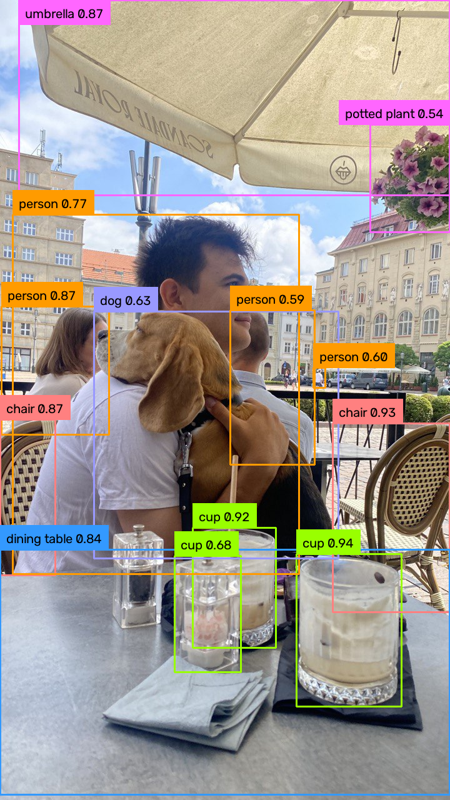

In [ ]:
import numpy as np
import supervision as sv

from PIL import Image

from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES

image = Image.open("dog-2.jpeg")

model = RFDETRMedium(resolution=640)
model.optimize_for_inference()

detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image.thumbnail((800, 800))
annotated_image

## Download Dataset from Roboflow Universe

In [5]:
from roboflow import download_dataset

dataset = download_dataset("https://universe.roboflow.com/new-workspace-4e9wd/sawit-8npnv/2", "coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sawit-2 in coco:: 100%|██████████| 5366/5366 [00:01<00:00, 4383.05it/s]


## Train RF-DETR on custom dataset

### Choose the right `batch_size`

In [ ]:
from rfdetr import RFDETRNano

model = RFDETRNano()

model.train(dataset_dir=dataset.location, epochs=10, batch_size=4, grad_accum_steps=4)

[2026-09-28 05:09:41] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-09-28 05:09:41] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-28 05:09:41] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-28 05:09:44] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-09-28 05:09:46] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-nano.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-09-28 05:09:48] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-28 05:09:48] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-28 05:09:49] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

Trainable params: 30.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.2 M                                                                                               
Total estimated model params size (MB): 120.603                                                                    
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-09-28 05:09:54] [INFO] rf-detr - Best EMA mAP improved to 0.0255 (epoch 0)
[2026-09-28 05:24:32] [INFO] rf-detr - Best regular checkpoint saved to /content/output/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.660274)
[2026-09-28 05:24:38] [INFO] rf-detr - Best EMA mAP improved to 0.6708 (epoch 0)
[2026-09-28 05:39:22] [INFO] rf-detr - Best regular checkpoint saved to /content/output/checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.673983)
[2026-09-28 05:39:28] [INFO] rf-detr - Best EMA mAP improved to 0.6862 (epoch 1)
[2026-09-28 05:54:09] [INFO] rf-detr - Best EMA mAP improved to 0.6936 (epoch 2)
[2026-09-28 06:09:18] [INFO] rf-detr - Best regular checkpoint saved to /content/output/checkpoint_best_regular.pth (epoch 3, monitor=val/mAP_50_95, value=0.7008)
[2026-09-28 06:09:24] [INFO] rf-detr - Best EMA mAP improved to 0.7001 (epoch 3)
[2026-09-28 06:24:16] [INFO] rf-detr - Best regular checkpoint saved to /content/output/checkpoint_bes

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-09-28 07:39:19] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.7250, ema=0.7304)


## Environment & Google Drive Setup

In [ ]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

shutil.copytree('/content/output', '/content/drive/MyDrive/RFDETR_Output_Nano')
print("Model dan hasil training berhasil tersimpan di Google Drive!")

Mounted at /content/drive
Model dan hasil training berhasil tersimpan di Google Drive!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Evaluate Fine-tuned RF-DETR Model

In [ ]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [ ]:
cleanup_gpu_memory(model, verbose=True)

In [ ]:
from rfdetr import RFDETRNano

model = RFDETRNano(pretrain_weights="/content/drive/MyDrive/RFDETR_Output_Nano/checkpoint_best_total.pth")
model.optimize_for_inference()
print("Model berhasil dimuat dari Google Drive!")

target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
[2026-09-28 14:24:25] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-28 14:24:25] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-28 14:24:33] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.
[2026-09-28 14:24:33] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Converting a t

Model berhasil dimuat dari Google Drive!


In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [ ]:
import supervision as sv
from PIL import Image
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 285/285 [00:10<00:00, 26.47it/s]


In [ ]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.716
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.979
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.898
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.405
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.732
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.641


## Run Inference with Fine-tuned RF-DETR Model

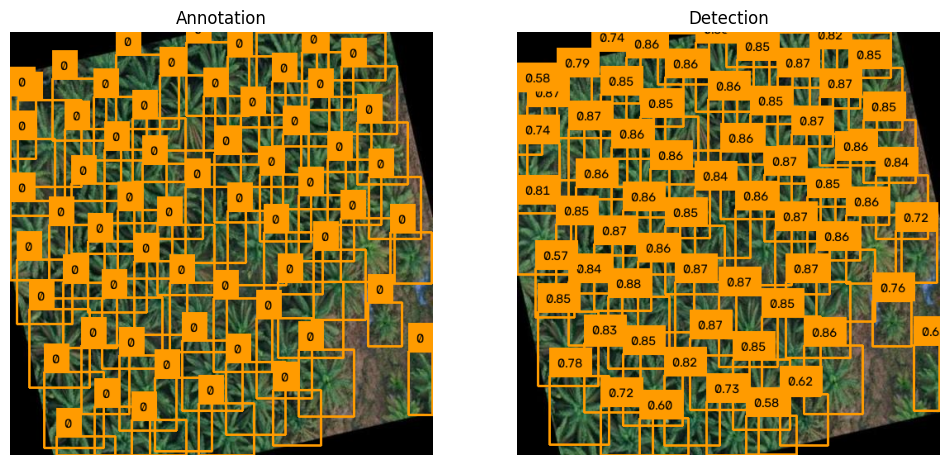

In [ ]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

In [ ]:
!pip install -q inference

In [ ]:
from inference import get_model

MODEL_ID = "sawit-8npnv/2"
model_rf = get_model(model_id=MODEL_ID, api_key = userdata.get("ROBOFLOW_API_KEY"))

In [ ]:
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

result = model_rf.infer(image, confidence=0.3)[0]
detections = sv.Detections.from_inference(result)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

[2026-09-29 03:23:33] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-29 03:23:33] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[2026-09-29 03:23:34] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.
[2026-09-29 03:23:34] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-09-29 03:23:34] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).


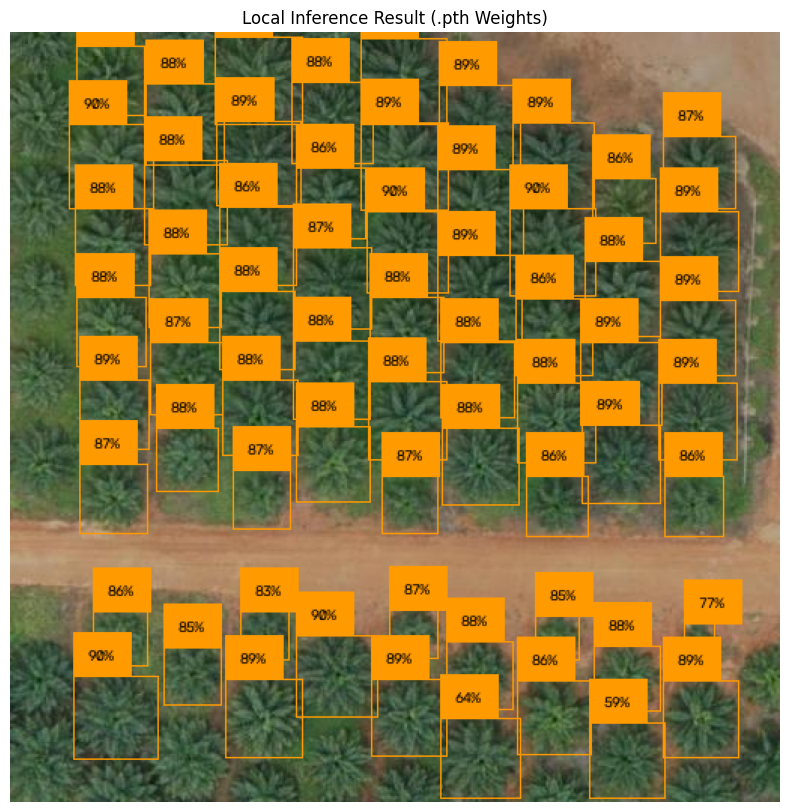

In [7]:
import torch
import glob
import matplotlib.pyplot as plt
from rfdetr import RFDETRNano
import supervision as sv
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

WEIGHTS_PATH = "/content/drive/MyDrive/RFDETR_Output_Nano/checkpoint_best_total.pth"

model_local = RFDETRNano(pretrain_weights=WEIGHTS_PATH)

test_images = glob.glob(f"{dataset.location}/test/*.jpg") + glob.glob(f"{dataset.location}/test/*.png")
image = Image.open(test_images[0])

result = model_local.predict(image, confidence=0.3)

text_scale = 0.35
thickness = 1
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080"
])

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(color=color, text_color=sv.Color.BLACK, text_scale=text_scale)

detections_labels = [f"{confidence*100:.0f}%" for confidence in result.confidence]

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, result)
detections_image = label_annotator.annotate(detections_image, result, detections_labels)

plt.figure(figsize=(10, 10))
plt.imshow(detections_image)
plt.title("Local Inference Result (.pth Weights)")
plt.axis("off")
plt.show()